# Phase 3 Project — MNIST Handwritten Digit Classifier

A multi-class image classifier built entirely from Phase 3 pieces:
`torchvision`'s `MNIST` dataset + `DataLoader` for batching, an
`nn.Sequential` MLP, `nn.CrossEntropyLoss` + `optim.Adam`, the standard
training loop, `train()`/`eval()` mode switching, and saving/loading a
`state_dict`.

**The task:** classify 28x28 grayscale images of handwritten digits (0-9).
MNIST has 60,000 training images and 10,000 held-out test images.

## Model architecture
```
Input image (1, 28, 28)
      |  flatten
   784 values
      |  Linear(784 -> 128) + ReLU
   128 values
      |  Linear(128 -> 64) + ReLU
    64 values
      |  Linear(64 -> 10)
   10 logits (one per digit class 0-9, fed into CrossEntropyLoss)
```


## Section 1 — Load the Data

`transforms.ToTensor()` converts a PIL image into a `FloatTensor` of shape
`(1, 28, 28)` (1 channel, since MNIST is grayscale) with pixel values
scaled from `[0, 255]` to `[0.0, 1.0]`.

`train=True` / `train=False` select the training split vs the held-out test
split — using the same split for both would let the model "cheat" by being
evaluated on data it already memorized.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

transform = transforms.ToTensor()   # PIL image -> FloatTensor, shape (1,28,28), scaled to [0,1]

train_data = MNIST(root="data", train=True, download=True, transform=transform)
test_data = MNIST(root="data", train=False, download=True, transform=transform)   # held-out split

print(f"Train samples: {len(train_data)}")
print(f"Test samples : {len(test_data)}")

image, label = train_data[0]
print(f"\nOne sample: image shape={image.shape}, dtype={image.dtype}, label={label}")

Using device: mps


100.0%
100.0%
100.0%
100.0%

Train samples: 60000
Test samples : 10000

One sample: image shape=torch.Size([1, 28, 28]), dtype=torch.float32, label=5


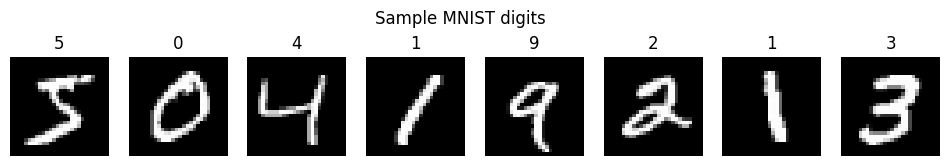

In [2]:
# ── VISUALIZE A FEW SAMPLES ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap="gray")   # squeeze drops the (1,) channel dim for display
    ax.set_title(str(label))
    ax.axis("off")
plt.suptitle("Sample MNIST digits")
plt.show()

## Section 2 — Wrap in `DataLoader`s

`shuffle=True` on the training loader means each epoch sees the data in a
different order, so the model can't accidentally learn something from batch
ordering. The test loader doesn't need shuffling since we only read through
it once per evaluation.

In [3]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}  (batch_size=64)")
print(f"Test batches : {len(test_loader)}")

images, labels = next(iter(train_loader))
print(f"\nOne batch: images shape={images.shape}, labels shape={labels.shape}")

Train batches: 938  (batch_size=64)
Test batches : 157

One batch: images shape=torch.Size([64, 1, 28, 28]), labels shape=torch.Size([64])


## Section 3 — Define the Model

A plain MLP (multi-layer perceptron): flatten the 28x28 image into a
784-length vector, then two hidden `Linear + ReLU` blocks, then a final
`Linear(64, 10)` producing one raw logit per digit class. The flatten step
lives inside `forward()`, so the model accepts a raw batch of images
straight from the `DataLoader` — no manual reshaping needed in the training
loop.

In [4]:
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10),   # raw logits -- CrossEntropyLoss applies softmax internally
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten (batch, 1, 28, 28) -> (batch, 784)
        return self.net(x)

model = DigitModel().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")

DigitModel(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total trainable parameters: 109,386


## Section 4 — Loss & Optimizer

`CrossEntropyLoss` for multi-class classification (10 digit classes),
`Adam` as the optimizer — the same combination introduced in Phase 3.

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Section 5 — Training Loop

The standard 5-step pattern from Phase 3, run over every batch in every
epoch. `model.train()` puts the model in training mode (matters once layers
like `Dropout`/`BatchNorm` are involved).

Epoch 1/5 | Avg Loss: 0.3421
Epoch 2/5 | Avg Loss: 0.1402
Epoch 3/5 | Avg Loss: 0.0960
Epoch 4/5 | Avg Loss: 0.0717
Epoch 5/5 | Avg Loss: 0.0563


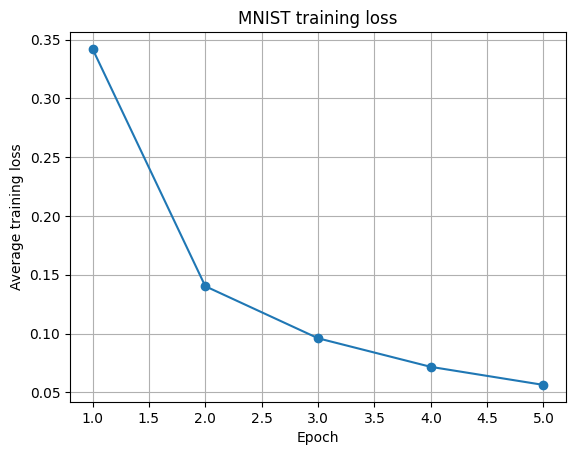

In [6]:
epochs = 5
loss_history = []

model.train()
for epoch in range(epochs):
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1}/{epochs} | Avg Loss: {avg_loss:.4f}")

plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("MNIST training loss")
plt.grid(True)
plt.show()

## Section 6 — Evaluation

`model.eval()` + `torch.no_grad()` — no dropout/batchnorm randomness, and no
computation graph is built since we don't need gradients for inference.
Accuracy is measured on `test_data`, which the model never saw during
training.

In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test accuracy: {accuracy:.2f}%  ({correct}/{total} correct)")

Test accuracy: 97.43%  (9743/10000 correct)


## Section 7 — Visualize Predictions

A grid of random test images with the model's prediction vs the true label
— green for correct, red for wrong. This is far more informative than
checking a single hardcoded example.

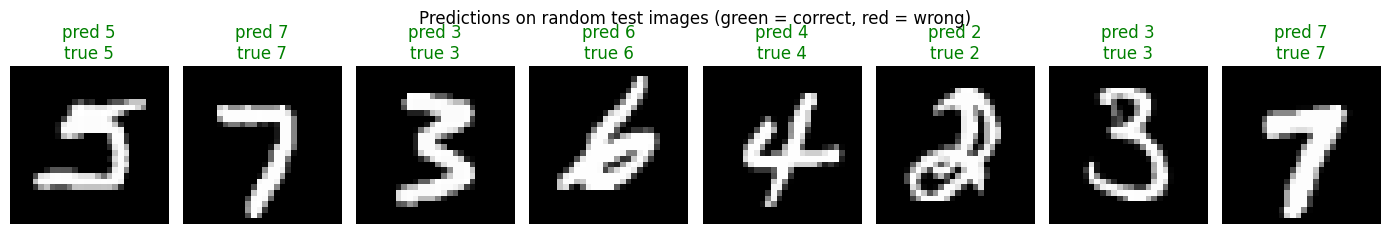

In [8]:
model.eval()
n_show = 8
indices = torch.randint(0, len(test_data), (n_show,))

fig, axes = plt.subplots(1, n_show, figsize=(14, 2.4))
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        image, true_label = test_data[idx]
        input_batch = image.unsqueeze(0).to(device)   # add batch dim -> (1, 1, 28, 28)
        predicted_label = model(input_batch).argmax(dim=1).item()

        ax.imshow(image.squeeze(), cmap="gray")
        is_correct = predicted_label == true_label
        ax.set_title(f"pred {predicted_label}\ntrue {true_label}",
                     color="green" if is_correct else "red")
        ax.axis("off")

plt.suptitle("Predictions on random test images (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Section 8 — Save & Reload the Model

Same pattern as Phase 3: save the `state_dict`, then reload it into a fresh
`DigitModel` and confirm it produces identical predictions.

In [9]:
save_path = "mnist_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Reload into a fresh model with the SAME architecture, and confirm it predicts identically
reloaded = DigitModel().to(device)
reloaded.load_state_dict(torch.load(save_path, map_location=device))
reloaded.eval()

with torch.no_grad():
    image, true_label = test_data[0]
    input_batch = image.unsqueeze(0).to(device)
    original_pred = model(input_batch).argmax(dim=1).item()
    reloaded_pred = reloaded(input_batch).argmax(dim=1).item()

print(f"Original model prediction : {original_pred}")
print(f"Reloaded model prediction : {reloaded_pred}   (should match)")

Model saved to mnist_model.pth
Original model prediction : 7
Reloaded model prediction : 7   (should match)


## Project Summary & Next Steps

```
Pipeline built:
  torchvision.datasets.MNIST(train=True/False) -> DataLoader(batch_size, shuffle)
  -> DigitModel (flatten -> Linear+ReLU -> Linear+ReLU -> Linear)
  -> CrossEntropyLoss + Adam -> standard training loop
  -> model.eval() + torch.no_grad() -> accuracy on a genuinely held-out test set
  -> state_dict saved to mnist_model.pth and reloaded to confirm it matches
```

**Where this MLP falls short:** flattening the image to a 784-length vector
throws away all 2D spatial structure — a pixel's neighbors carry no special
meaning to a `Linear` layer. A **Convolutional Neural Network** (`nn.Conv2d`)
preserves that structure with small, shared filters that slide across the
image, and is the standard next step for image tasks — a natural Phase 4.